<a href="https://colab.research.google.com/github/grownsandip/ML_Algo/blob/main/Salary_prediction_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

first we load google drive into the environment

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
path="/content/drive/MyDrive/SALARY_DATA/SALARY_DATA.xlsx"
data=pd.read_excel(path)
print(data)

            Position  Level   Slaray
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000


In [5]:
# Splitting the dataset
X = data.iloc[:, 1:2].values
y = data.iloc[:, 2].values
print("x",X)
print("Y:",y)

x [[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
Y: [  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [6]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=10,random_state=0) # we have 10 trees in the forest
regressor.fit(X, y)

RandomForestRegressor(n_estimators=10, random_state=0)

<ipython-input-8-3d0f0be67453>:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)


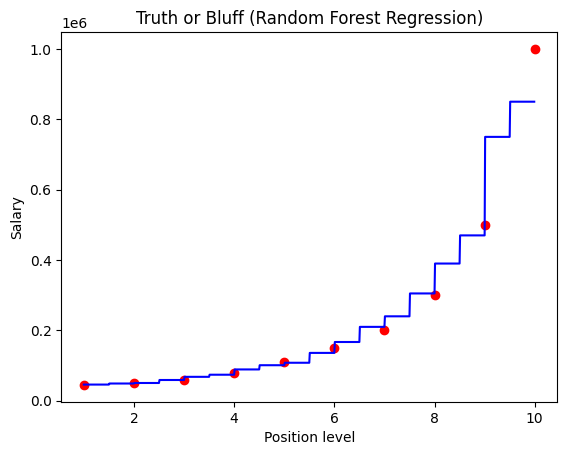

In [8]:
import matplotlib.pyplot as plt
import numpy as np
X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color = 'red')
plt.plot(X_grid, regressor.predict(X_grid), color = 'blue')
plt.title('Truth or Bluff (Random Forest Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

In [11]:
from sklearn.tree import plot_tree

# Extract the first tree from the random forest
tree = regressor.estimators_[1] # this index value is the index of tree we are selecting

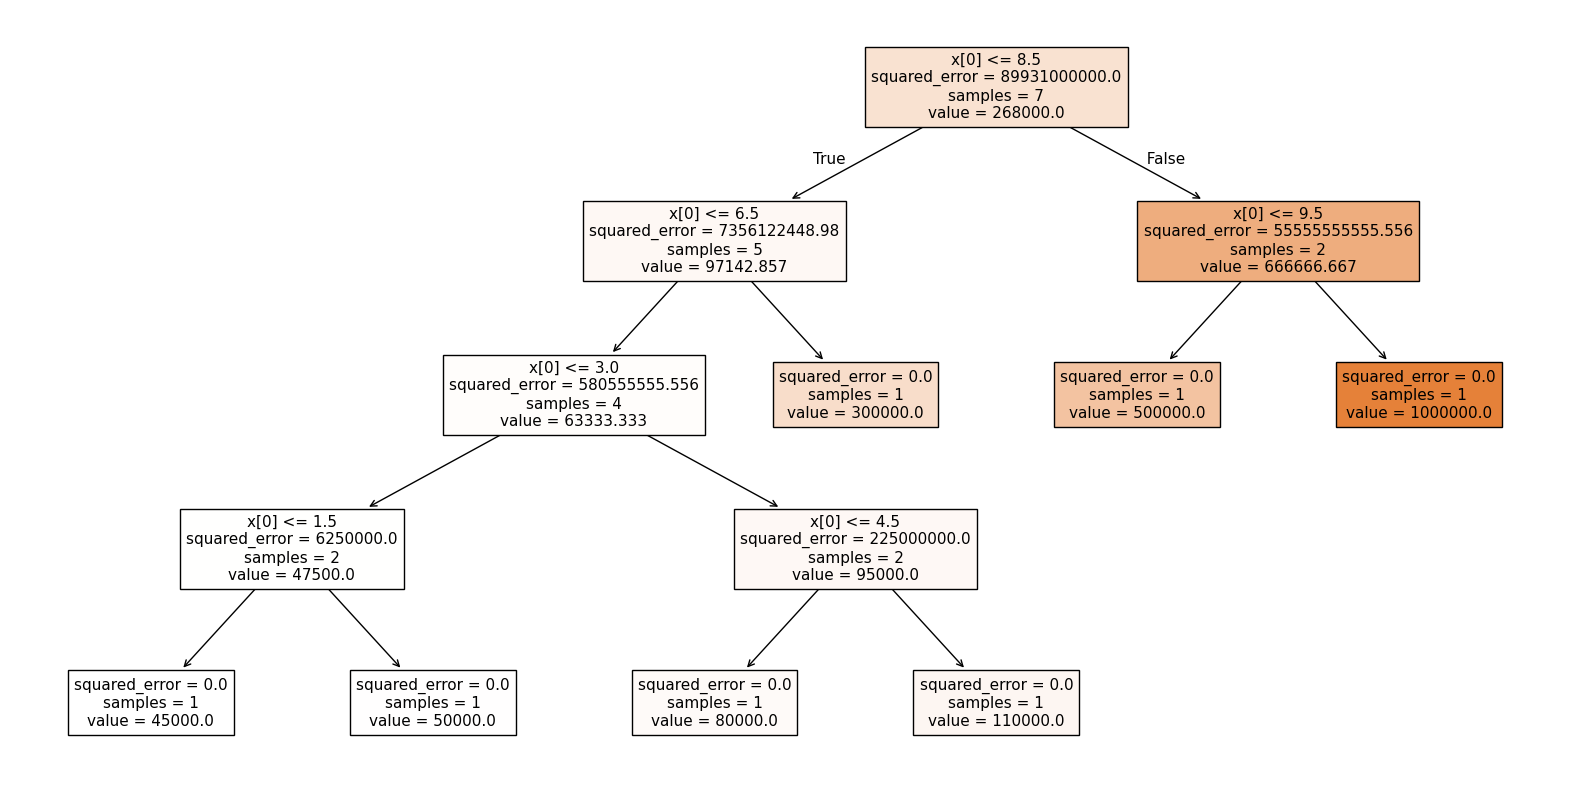

In [12]:
# Plot the extracted tree
plt.figure(figsize=(20, 10))
plot_tree(tree, filled=True)
plt.show()

In [13]:
sample_input = pd.DataFrame([[12]], columns=['Level'])

# Making prediction
print(regressor.predict(sample_input))

[850000.]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
